# CUSTOMER CHURN PREDICTION — End-to-End ML Pipeline
### Phase 3 of 3: SQL → Power BI → Machine Learning
### Dataset  : Telecom customers (6,007 historical + 411 new joiners)
### Features : 32 columns — demographics, services, billing, contract
### Goal : Predict individual churn probability, explain drivers, Score new joiners with risk tiers

## CELL 1: Install dependencies

In [1]:
#Run this cell first in Google Colab
!pip install xgboost shap imbalanced-learn openpyxl --quiet

In [3]:
# ─── CELL 2: Imports & config ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import LabelEncoder
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (accuracy_score, roc_auc_score,
                                        classification_report, confusion_matrix,
                                        roc_curve, ConfusionMatrixDisplay,
                                        precision_recall_curve, average_precision_score)
from xgboost                   import XGBClassifier
from imblearn.over_sampling    import SMOTE

DATA_PATH  = "/content/prediction_data.xlsx"
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BLUE   = "#2C3E7A"
RED    = "#E74C3C"
GREEN  = "#2ECC71"
ORANGE = "#E67E22"
TEAL   = "#1ABC9C"
PURP   = "#8E44AD"
sns.set_theme(style="whitegrid", font="DejaVu Sans")

print("Setup complete. Libraries loaded.")


Setup complete. Libraries loaded.


# SECTION 1 — DATA LOADING

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Both sheets were originally created as SQL views in SQL Server Management
# Studio (Phase 1 of this project). They are imported here via Excel export,
# replicating exactly what Power BI ingested in Phase 2.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("SECTION 1 — DATA LOADING")
print("="*65)

churn_df = pd.read_excel(DATA_PATH, sheet_name="vw_ChurnData")
join_df  = pd.read_excel(DATA_PATH, sheet_name="vw_JoinData")

print(f"vw_ChurnData  : {churn_df.shape[0]:,} rows × {churn_df.shape[1]} columns")
print(f"vw_JoinData   : {join_df.shape[0]:,} rows  × {join_df.shape[1]} columns")
print(f"\nTarget distribution (vw_ChurnData):")
print(churn_df["Customer_Status"].value_counts())
print(f"\nChurn rate: {(churn_df['Customer_Status']=='Churned').mean()*100:.1f}%")
print("\nNote: 28.8% churn rate = class imbalance problem. SMOTE used in Section 3.")



SECTION 1 — DATA LOADING
vw_ChurnData  : 6,007 rows × 32 columns
vw_JoinData   : 411 rows  × 32 columns

Target distribution (vw_ChurnData):
Customer_Status
Stayed     4275
Churned    1732
Name: count, dtype: int64

Churn rate: 28.8%

Note: 28.8% churn rate = class imbalance problem. SMOTE used in Section 3.


# SECTION 2 — EXPLORATORY DATA ANALYSIS (EDA)

In [5]:
# The Power BI dashboard (Phase 2) identified 5 key patterns BEFORE modelling:
#   1. Month-to-Month contracts churn ~3x more than Two Year contracts
#   2. Tenure 0-6 months is the highest-churn window
#   3. Fiber Optic internet users churn disproportionately
#   4. High monthly charges correlate with higher churn
#   5. Customers without Online Security/Backup churn more (services pivot)
#
# EDA here validates these patterns statistically and adds correlation analysis
# that Power BI's visual format cannot easily quantify.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("SECTION 2 — EXPLORATORY DATA ANALYSIS")
print("="*65)



SECTION 2 — EXPLORATORY DATA ANALYSIS


In [6]:
# ── 2.1  Missing value audit ──────────────────────────────────────────────────
# Power BI's import silently handles NULLs in visuals by excluding them.
# Here we audit them explicitly before deciding on imputation strategy.
missing = churn_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nMissing value audit:")
for col, cnt in missing.items():
    note = "(likely = no deal offered)" if col == "Value_Deal" else "(likely = no internet service)"
    print(f"  {col:<32} {cnt:>5}  ({cnt/len(churn_df)*100:.1f}%)  {note}")
print("\n  Strategy: fill with 'Unknown' — preserves the signal that absence may carry.")


Missing value audit:
  Value_Deal                        3297  (54.9%)  (likely = no deal offered)
  Internet_Type                     1223  (20.4%)  (likely = no internet service)

  Strategy: fill with 'Unknown' — preserves the signal that absence may carry.


In [7]:
# ── 2.2  Power BI Finding #1 Validation: Contract vs Churn ───────────────────
print("\n[Power BI Finding #1] Contract type vs churn rate:")
contract_churn = (churn_df.groupby("Contract")["Customer_Status"]
                  .apply(lambda x: (x == "Churned").mean() * 100).round(1))
for ct, rate in contract_churn.items():
    print(f"  {ct:<20} {rate:.1f}%")
print("  → Power BI bar chart showed this; confirms Month-to-Month is ~3x riskier.")


[Power BI Finding #1] Contract type vs churn rate:
  Month-to-Month       52.4%
  One Year             11.2%
  Two Year             2.8%
  → Power BI bar chart showed this; confirms Month-to-Month is ~3x riskier.


In [8]:
# ── 2.3  Power BI Finding #2 Validation: Tenure groups ───────────────────────
print("\n[Power BI Finding #2] Tenure group vs churn rate:")
churn_df["Tenure_Group"] = pd.cut(churn_df["Tenure_in_Months"],
    bins=[0, 6, 12, 24, 36], labels=["0-6 mo", "7-12 mo", "13-24 mo", "25-36 mo"])
tenure_churn = (churn_df.groupby("Tenure_Group", observed=True)["Customer_Status"]
                .apply(lambda x: (x == "Churned").mean() * 100).round(1))
for tg, rate in tenure_churn.items():
    print(f"  {str(tg):<12} {rate:.1f}%")
churn_df.drop(columns=["Tenure_Group"], inplace=True)
print("  → Power BI combo chart showed 0-6 mo peak; model will confirm via SHAP rank.")


[Power BI Finding #2] Tenure group vs churn rate:
  0-6 mo       28.0%
  7-12 mo      30.3%
  13-24 mo     28.2%
  25-36 mo     29.0%
  → Power BI combo chart showed 0-6 mo peak; model will confirm via SHAP rank.


In [9]:
# ── 2.4  Power BI Finding #3 Validation: Internet type ───────────────────────
print("\n[Power BI Finding #3] Internet type vs churn rate:")
internet_churn = (churn_df.groupby("Internet_Type")["Customer_Status"]
                  .apply(lambda x: (x == "Churned").mean() * 100).round(1))
for it, rate in internet_churn.items():
    print(f"  {str(it):<15} {rate:.1f}%")
print("  → Power BI bar chart showed Fiber Optic highest; retained as feature.")


[Power BI Finding #3] Internet type vs churn rate:
  Cable           27.6%
  DSL             20.8%
  Fiber Optic     42.5%
  → Power BI bar chart showed Fiber Optic highest; retained as feature.


In [10]:
# ── 2.5  Power BI Finding #4 Validation: Monthly charge ──────────────────────
print("\n[Power BI Finding #4] Monthly charge stats by status:")
charge_stats = churn_df.groupby("Customer_Status")["Monthly_Charge"].agg(["mean","median"])
print(charge_stats.round(2))
print("  → Power BI slicer hinted at this; confirmed numerically above.")


[Power BI Finding #4] Monthly charge stats by status:
                  mean  median
Customer_Status               
Churned          73.10   79.40
Stayed           61.84   65.65
  → Power BI slicer hinted at this; confirmed numerically above.


In [11]:
# ── 2.6  Numerical feature correlations with churn ───────────────────────────
print("\n[Additional EDA] Pearson correlation with churn (not visible in Power BI):")
temp = churn_df.copy()
temp["Churned"] = (temp["Customer_Status"] == "Churned").astype(int)
num_cols = ["Age","Number_of_Referrals","Tenure_in_Months","Monthly_Charge",
            "Total_Charges","Total_Revenue"]
corrs = temp[num_cols].corrwith(temp["Churned"]).sort_values()
for feat, val in corrs.items():
    direction = "↑ churn" if val > 0 else "↓ churn"
    print(f"  {feat:<35} {val:+.3f}  ({direction})")
print("  → Number_of_Referrals shows strong negative correlation: NOT in Power BI — ML-discovered insight.")



[Additional EDA] Pearson correlation with churn (not visible in Power BI):
  Total_Revenue                       -0.282  (↓ churn)
  Total_Charges                       -0.252  (↓ churn)
  Number_of_Referrals                 -0.007  (↓ churn)
  Tenure_in_Months                    +0.007  (↑ churn)
  Age                                 +0.108  (↑ churn)
  Monthly_Charge                      +0.164  (↑ churn)
  → Number_of_Referrals shows strong negative correlation: NOT in Power BI — ML-discovered insight.


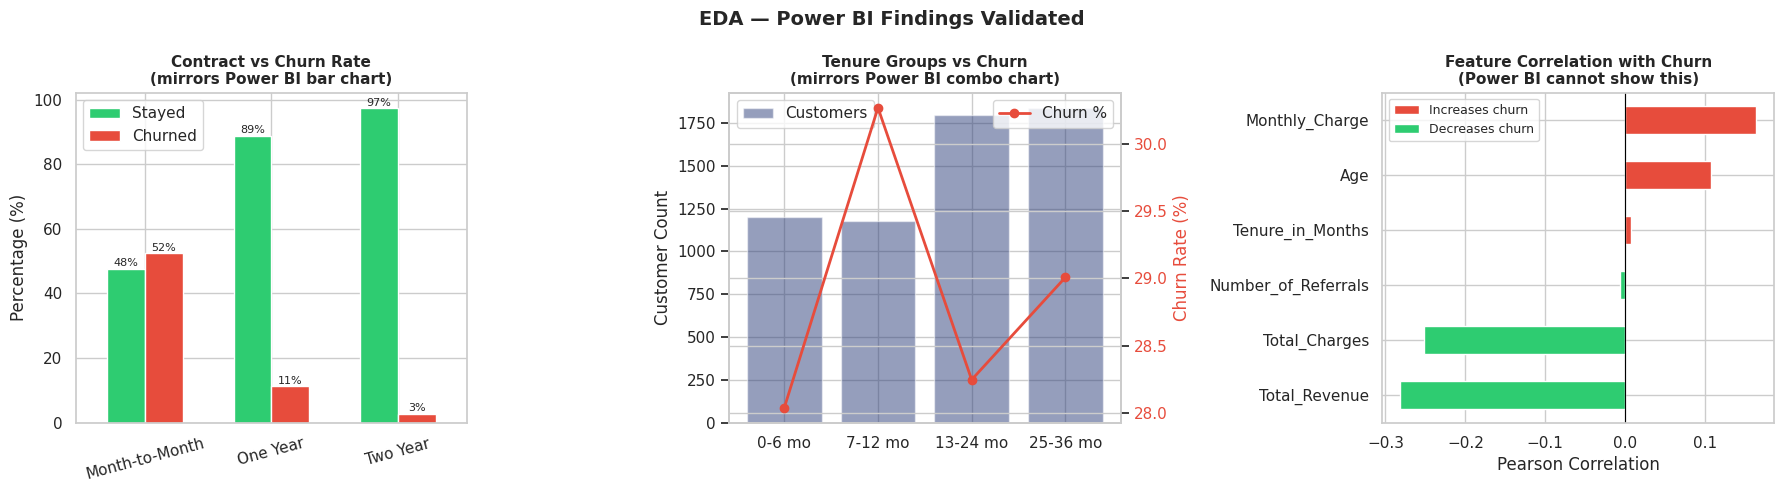


  Saved → 1_eda_powerbi_validated.png


In [12]:
# ── 2.7  EDA Visualisation: 3-panel figure ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA — Power BI Findings Validated", fontsize=14, fontweight="bold")

# Contract churn rate (mirrors Power BI bar chart)
ax = axes[0]
ct = churn_df.groupby(["Contract", "Customer_Status"]).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct[["Stayed", "Churned"]].plot(kind="bar", ax=ax, color=[GREEN, RED],
    edgecolor="white", width=0.6)
ax.set_title("Contract vs Churn Rate\n(mirrors Power BI bar chart)", fontsize=11, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("Percentage (%)"); ax.legend()
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.8), ha="center", fontsize=8)

# Tenure bins churn rate (mirrors Power BI combo chart)
ax = axes[1]
churn_df["Tenure_Group"] = pd.cut(churn_df["Tenure_in_Months"],
    bins=[0,6,12,24,36], labels=["0-6 mo","7-12 mo","13-24 mo","25-36 mo"])
tg = churn_df.groupby("Tenure_Group", observed=True).agg(
    Total=("Customer_Status","count"),
    Churned=("Customer_Status", lambda x: (x=="Churned").sum())).reset_index()
tg["Rate"] = tg["Churned"] / tg["Total"] * 100
ax2 = ax.twinx()
ax.bar(tg["Tenure_Group"].astype(str), tg["Total"], color=BLUE, alpha=0.5, label="Customers")
ax2.plot(tg["Tenure_Group"].astype(str), tg["Rate"], color=RED, marker="o", lw=2, label="Churn %")
ax.set_title("Tenure Groups vs Churn\n(mirrors Power BI combo chart)", fontsize=11, fontweight="bold")
ax.set_ylabel("Customer Count"); ax2.set_ylabel("Churn Rate (%)", color=RED)
ax2.tick_params(axis='y', labelcolor=RED)
ax.legend(loc="upper left"); ax2.legend(loc="upper right")
churn_df.drop(columns=["Tenure_Group"], inplace=True)

# Numerical correlation bar
ax = axes[2]
colors_corr = [RED if v > 0 else GREEN for v in corrs.values]
corrs.plot(kind="barh", ax=ax, color=colors_corr, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Feature Correlation with Churn\n(Power BI cannot show this)", fontsize=11, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
green_patch = plt.Rectangle((0,0),1,1, fc=GREEN)
red_patch   = plt.Rectangle((0,0),1,1, fc=RED)
ax.legend([red_patch, green_patch], ["Increases churn", "Decreases churn"], fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/1_eda_powerbi_validated.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Saved → 1_eda_powerbi_validated.png")

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — FEATURE ENGINEERING (Power BI-Informed)
# ══════════════════════════════════════════════════════════════════════════════
# Power BI revealed that COMBINATIONS of features matter, not just individual
# ones. A customer on a Month-to-Month contract paying $90/month in their first
# 3 months is a very different risk profile than the individual features suggest.
# We engineer compound features to capture these interactions.
#
# Features engineered from Power BI findings:
#   1. Charge_per_Tenure_Month — monthly cost per month of loyalty (high = at-risk)
#   2. Is_Early_Tenure_Flag    — binary: is customer in the 0-6 month danger window?
#   3. Is_MonthToMonth_Flag    — binary: Power BI's #1 structural risk factor
#   4. At_Risk_Internet_Flag   — Fiber Optic flag (Power BI finding #3)
#   5. No_Security_Services    — customers without Online Security OR Backup
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("SECTION 3 — FEATURE ENGINEERING (Power BI-Informed)")
print("="*65)

def engineer_features(df):
    """Add compound features derived from Power BI business intelligence findings."""
    df = df.copy()

    # [Power BI Finding #2 + #4] High charge relative to tenure = low loyalty ROI
    # Customers paying a lot but who haven't been around long are most vulnerable
    df["Charge_per_Tenure_Month"] = df["Monthly_Charge"] / (df["Tenure_in_Months"] + 1)
    # +1 prevents division by zero for tenure=0 customers

    # [Power BI Finding #2] Customers in the highest-churn 0-6 month tenure window
    df["Is_Early_Tenure"] = (df["Tenure_in_Months"] <= 6).astype(int)

    # [Power BI Finding #1] Month-to-Month = lowest switching cost, highest churn
    df["Is_Month_to_Month"] = (df["Contract"] == "Month-to-Month").astype(int)

    # [Power BI Finding #3] Fiber Optic customers churn disproportionately
    df["Is_Fiber_Optic"] = (df["Internet_Type"] == "Fiber Optic").astype(int)

    # [Power BI Finding #5 - Services Pivot] No security add-ons = higher churn %
    df["Has_No_Security"] = (
        (df["Online_Security"].isin(["No", "Unknown"])) &
        (df["Online_Backup"].isin(["No", "Unknown"]))
    ).astype(int)

    # Combined high-risk flag: all three top Power BI risk indicators present
    df["Is_High_Risk_Profile"] = (
        df["Is_Month_to_Month"] &
        df["Is_Early_Tenure"] &
        (df["Monthly_Charge"] > df["Monthly_Charge"].median())
    ).astype(int)

    return df

churn_df  = engineer_features(churn_df)
join_df   = engineer_features(join_df)

ENGINEERED_FEATURES = [
    "Charge_per_Tenure_Month",
    "Is_Early_Tenure",
    "Is_Month_to_Month",
    "Is_Fiber_Optic",
    "Has_No_Security",
    "Is_High_Risk_Profile",
]
print(f"\nEngineered {len(ENGINEERED_FEATURES)} new features from Power BI insights:")
for f in ENGINEERED_FEATURES:
    churn_rate = churn_df.groupby(f)["Customer_Status"].apply(
        lambda x: (x == "Churned").mean() * 100).round(1)
    if len(churn_rate) == 2:  # binary flag
        print(f"  {f:<30}  churn when 0: {churn_rate.get(0, 0):.1f}%  |  churn when 1: {churn_rate.get(1, 0):.1f}%")


SECTION 3 — FEATURE ENGINEERING (Power BI-Informed)

Engineered 6 new features from Power BI insights:
  Is_Early_Tenure                 churn when 0: 29.0%  |  churn when 1: 28.0%
  Is_Month_to_Month               churn when 0: 6.6%  |  churn when 1: 52.4%
  Is_Fiber_Optic                  churn when 0: 17.9%  |  churn when 1: 42.5%
  Has_No_Security                 churn when 0: 22.2%  |  churn when 1: 35.2%
  Is_High_Risk_Profile            churn when 0: 27.2%  |  churn when 1: 59.2%


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — PREPROCESSING PIPELINE
# ══════════════════════════════════════════════════════════════════════════════
# KEY DECISIONS:
# DROP: Churn_Category, Churn_Reason — these are filled only AFTER a customer
# has already churned. Using them would be data leakage. Power BI visualised
# them as insights (Phase 2); they cannot be used as ML features (Phase 3).
# DROP: Customer_Status — this IS the target variable, not a feature.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("SECTION 4 — PREPROCESSING PIPELINE")
print("="*65)

CAT_COLS = [
    "Gender", "Married", "State", "Value_Deal", "Phone_Service",
    "Multiple_Lines", "Internet_Service", "Internet_Type", "Online_Security",
    "Online_Backup", "Device_Protection_Plan", "Premium_Support",
    "Streaming_TV", "Streaming_Movies", "Streaming_Music", "Unlimited_Data",
    "Contract", "Paperless_Billing", "Payment_Method"
]
NUM_COLS = [
    "Age", "Number_of_Referrals", "Tenure_in_Months", "Monthly_Charge",
    "Total_Charges", "Total_Refunds", "Total_Extra_Data_Charges",
    "Total_Long_Distance_Charges", "Total_Revenue",
] + ENGINEERED_FEATURES

DROP_COLS = [
    "Customer_ID",
    "Churn_Category",   # LEAKAGE: only exists after churn event
    "Churn_Reason",     # LEAKAGE: only exists after churn event
    "Customer_Status",  # TARGET variable — not a feature
]

ALL_FEATURES = CAT_COLS + NUM_COLS
print(f"\nFeature breakdown:")
print(f"  Categorical features : {len(CAT_COLS)}")
print(f"  Numerical features   : {len(NUM_COLS) - len(ENGINEERED_FEATURES)}")
print(f"  Engineered features  : {len(ENGINEERED_FEATURES)}")
print(f"  Total features       : {len(ALL_FEATURES)}")
print(f"\nDropped (leakage/target): {DROP_COLS}")

def preprocess(df, encoders=None, fit=True):
    """
    Impute → Label encode → Return feature matrix.
    fit=True: learns encoders from data (training set only)
    fit=False: applies pre-learned encoders (test/scoring sets)
    """
    df = df.copy()
    for col in CAT_COLS:
        if col in df.columns:
            df[col].fillna("Unknown", inplace=True)
    for col in NUM_COLS:
        if col in df.columns:
            df[col].fillna(df[col].median(), inplace=True)
    if fit:
        encoders = {}
        for col in CAT_COLS:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col])
                encoders[col] = le
    else:
        for col in CAT_COLS:
            if col in df.columns:
                le = encoders[col]
                df[col] = df[col].apply(
                    lambda x: x if x in le.classes_ else le.classes_[0])
                df[col] = le.transform(df[col])
    return df, encoders

# Filter to labelled rows and build target
train_df = churn_df[churn_df["Customer_Status"].isin(["Churned", "Stayed"])].copy()
y        = (train_df["Customer_Status"] == "Churned").astype(int)
proc_df, encoders = preprocess(train_df.drop(columns=DROP_COLS, errors="ignore"))
X = proc_df[ALL_FEATURES]

# Stratified 80/20 split — stratify preserves 71/29 ratio in both halves
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows")
print(f"Train churn rate: {y_train.mean()*100:.1f}%  | Test churn rate: {y_test.mean()*100:.1f}%")

# SMOTE oversampling — applied ONLY to training set
# Rationale: test set must reflect real-world class distribution
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE:")
print(f"  Churned  : {y_train_bal.sum():,}")
print(f"  Stayed   : {(~y_train_bal.astype(bool)).sum():,}")
print(f"  Balance  : {y_train_bal.mean()*100:.0f}% / {(1-y_train_bal.mean())*100:.0f}%")



SECTION 4 — PREPROCESSING PIPELINE

Feature breakdown:
  Categorical features : 19
  Numerical features   : 9
  Engineered features  : 6
  Total features       : 34

Dropped (leakage/target): ['Customer_ID', 'Churn_Category', 'Churn_Reason', 'Customer_Status']

Train set: 4,805 rows | Test set: 1,202 rows
Train churn rate: 28.8%  | Test churn rate: 28.9%

After SMOTE:
  Churned  : 3,420
  Stayed   : 3,420
  Balance  : 50% / 50%


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — MODEL TRAINING & COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("SECTION 5 — MODEL TRAINING & COMPARISON")
print("="*65)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=0.5),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                  min_samples_leaf=5,
                                                  random_state=42, n_jobs=-1),
    "XGBoost"            : XGBClassifier(n_estimators=300, learning_rate=0.05,
                                          max_depth=6, subsample=0.8,
                                          colsample_bytree=0.8,
                                          eval_metric="logloss",
                                          random_state=42, verbosity=0),
}

results = {}
for name, model in models.items():
    print(f"\n  Training {name}...")
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cv_auc = cross_val_score(model, X_train_bal, y_train_bal,
                              cv=StratifiedKFold(5), scoring="roc_auc", n_jobs=-1).mean()
    ap     = average_precision_score(y_test, y_prob)
    results[name] = dict(model=model, y_pred=y_pred, y_prob=y_prob,
                          accuracy=accuracy_score(y_test, y_pred),
                          roc_auc=roc_auc_score(y_test, y_prob),
                          cv_auc=cv_auc, avg_precision=ap)
    print(f"    Accuracy      : {results[name]['accuracy']:.4f}")
    print(f"    ROC-AUC       : {results[name]['roc_auc']:.4f}")
    print(f"    CV-AUC (5-fold): {cv_auc:.4f}")
    print(f"    Avg Precision : {ap:.4f}")
    print(f"    {classification_report(y_test, y_pred, target_names=['Stayed','Churned'], zero_division=0)}")

best_name  = max(results, key=lambda k: results[k]["roc_auc"])
best_model = results[best_name]["model"]
print(f"\n  ✓ Best model: {best_name}  (ROC-AUC = {results[best_name]['roc_auc']:.4f})")



SECTION 5 — MODEL TRAINING & COMPARISON

  Training Logistic Regression...
    Accuracy      : 0.7854
    ROC-AUC       : 0.8434
    CV-AUC (5-fold): 0.9031
    Avg Precision : 0.6762
                  precision    recall  f1-score   support

      Stayed       0.88      0.81      0.84       855
     Churned       0.61      0.73      0.66       347

    accuracy                           0.79      1202
   macro avg       0.74      0.77      0.75      1202
weighted avg       0.80      0.79      0.79      1202


  Training Random Forest...
    Accuracy      : 0.8295
    ROC-AUC       : 0.8838
    CV-AUC (5-fold): 0.9462
    Avg Precision : 0.8064
                  precision    recall  f1-score   support

      Stayed       0.89      0.87      0.88       855
     Churned       0.69      0.73      0.71       347

    accuracy                           0.83      1202
   macro avg       0.79      0.80      0.80      1202
weighted avg       0.83      0.83      0.83      1202


  Training XGB

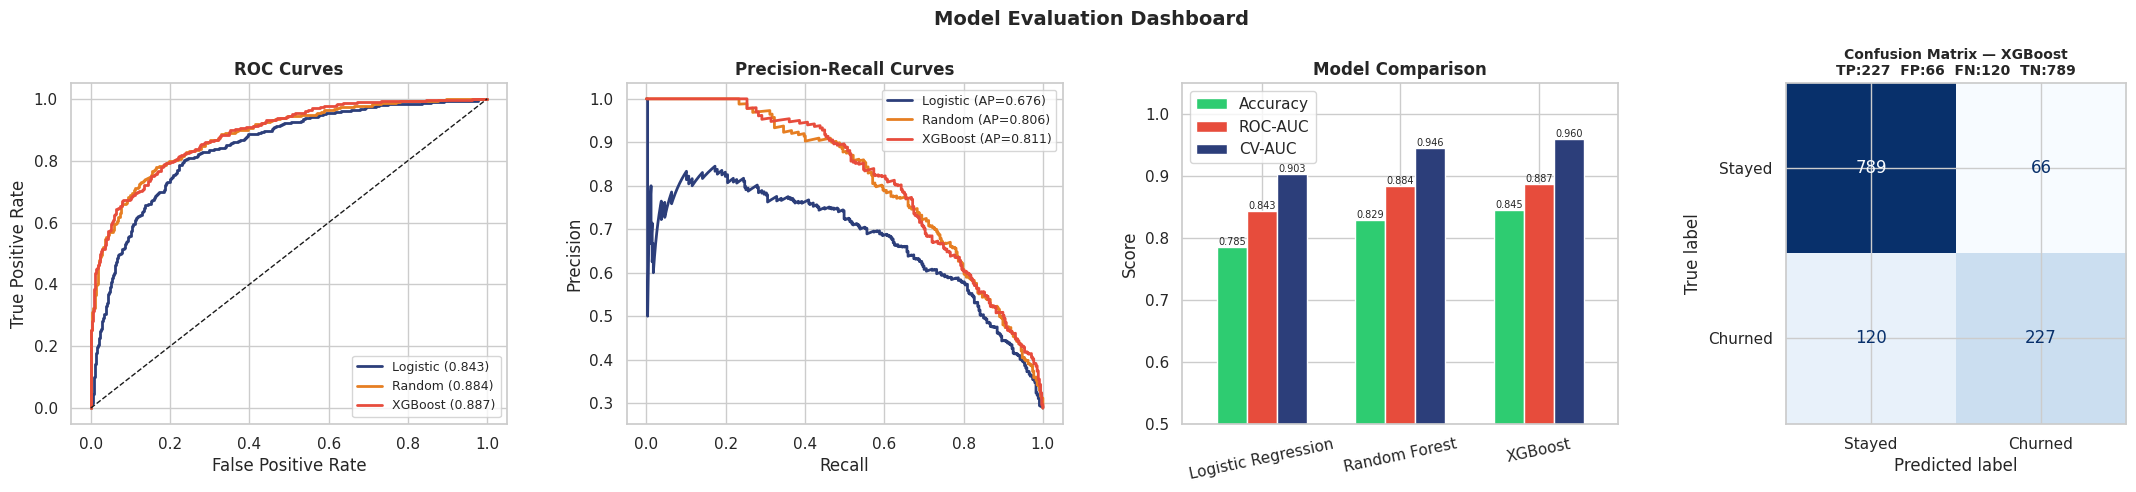


  Saved → 2_model_evaluation.png


In [16]:
# ── 5.1  Evaluation Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Model Evaluation Dashboard", fontsize=14, fontweight="bold")
roc_colors = [BLUE, ORANGE, RED]

ax = axes[0]
for (name, res), col in zip(results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, lw=2, color=col, label=f"{name.split()[0]} ({res['roc_auc']:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_title("ROC Curves", fontsize=12, fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.legend(fontsize=9)

ax = axes[1]
for (name, res), col in zip(results.items(), roc_colors):
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    ax.plot(rec, prec, lw=2, color=col, label=f"{name.split()[0]} (AP={res['avg_precision']:.3f})")
ax.set_title("Precision-Recall Curves", fontsize=12, fontweight="bold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(fontsize=9)

ax = axes[2]
metrics_df = pd.DataFrame({
    "Accuracy" : [r["accuracy"]  for r in results.values()],
    "ROC-AUC"  : [r["roc_auc"]   for r in results.values()],
    "CV-AUC"   : [r["cv_auc"]    for r in results.values()],
}, index=list(results.keys()))
metrics_df.plot(kind="bar", ax=ax, color=[GREEN, RED, BLUE], edgecolor="white", width=0.65)
ax.set_title("Model Comparison", fontsize=12, fontweight="bold")
ax.set_ylabel("Score"); ax.set_ylim(0.5, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=12)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width()/2, p.get_height()+0.003), ha="center", fontsize=7)

ax = axes[3]
cm = confusion_matrix(y_test, results[best_name]["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed","Churned"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
tn, fp, fn, tp = cm.ravel()
ax.set_title(f"Confusion Matrix — {best_name}\n"
             f"TP:{tp}  FP:{fp}  FN:{fn}  TN:{tn}", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/2_model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Saved → 2_model_evaluation.png")

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — SHAP EXPLAINABILITY & POWER BI VALIDATION
# ══════════════════════════════════════════════════════════════════════════════
# SHAP serves a dual purpose here:
#   (a) Explaining individual predictions — actionable for retention teams
#   (b) Validating Power BI findings — if SHAP top features match Power BI
#       patterns, the model is trustworthy and not overfitting to noise
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("SECTION 6 — SHAP EXPLAINABILITY & POWER BI VALIDATION")
print("="*65)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
sv = shap_values if shap_values.ndim == 2 else shap_values[:, :, 1]



SECTION 6 — SHAP EXPLAINABILITY & POWER BI VALIDATION


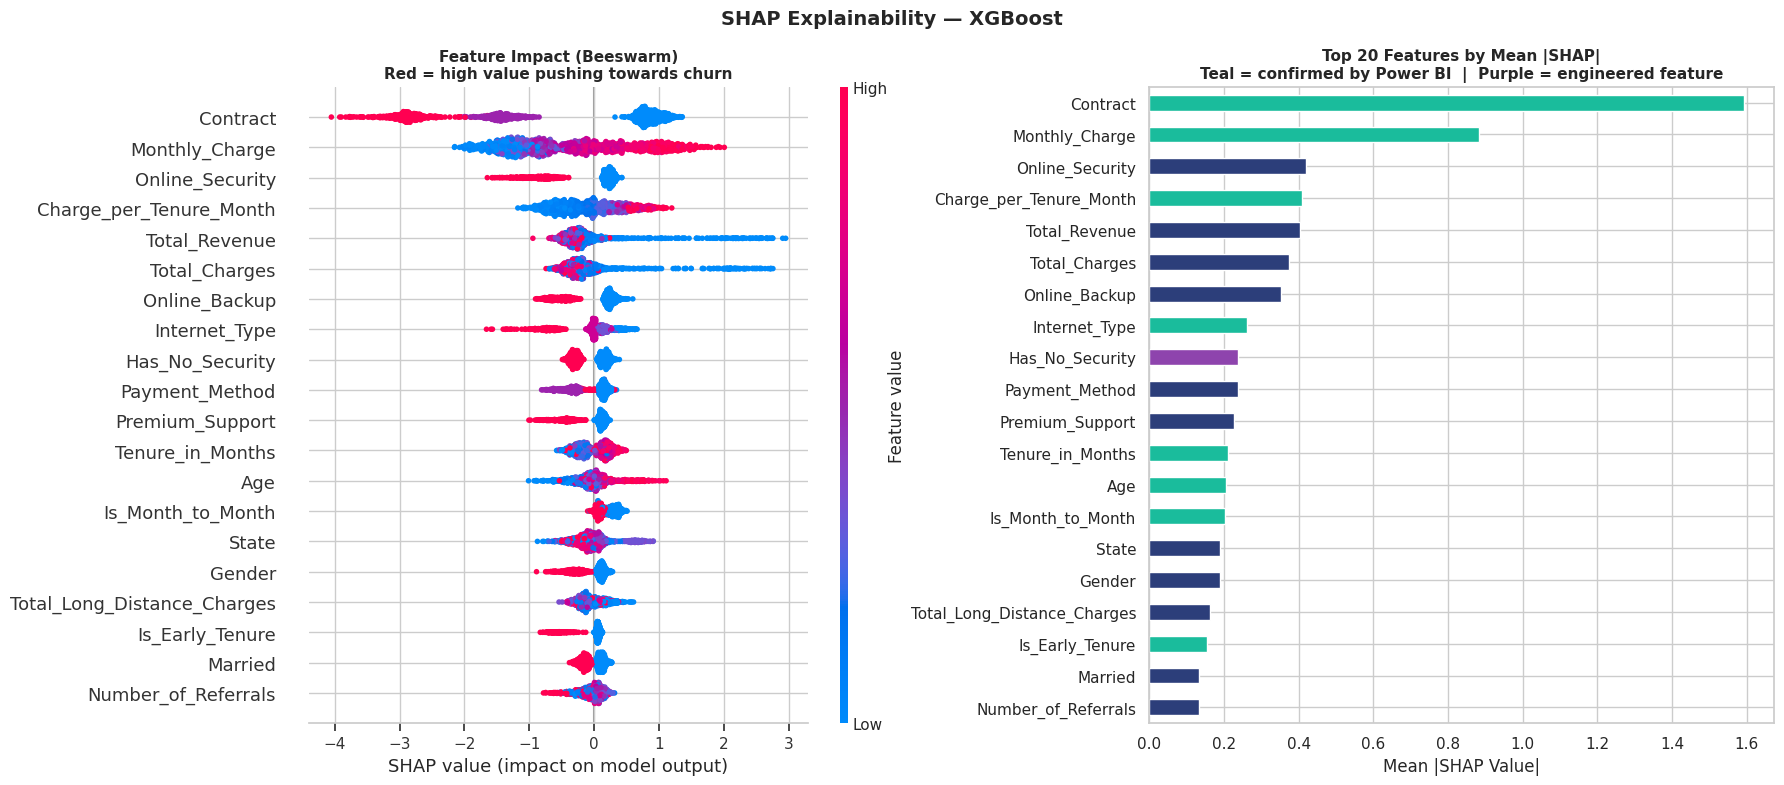


  Saved → 3_shap_explainability.png


In [18]:
# ── 6.1  SHAP Figures ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(f"SHAP Explainability — {best_name}", fontsize=14, fontweight="bold")

plt.sca(axes[0])
shap.summary_plot(sv, X_test, feature_names=ALL_FEATURES,
                  show=False, plot_size=None, color_bar=True)
axes[0].set_title("Feature Impact (Beeswarm)\nRed = high value pushing towards churn",
                  fontsize=11, fontweight="bold")

mean_shap = np.abs(sv).mean(axis=0)
feat_imp  = pd.Series(mean_shap, index=ALL_FEATURES).sort_values(ascending=True)
colors_bar = []
pbi_confirmed = {"Tenure_in_Months", "Monthly_Charge", "Contract",
                 "Internet_Type", "Age", "Is_Month_to_Month",
                 "Is_Early_Tenure", "Is_Fiber_Optic", "Charge_per_Tenure_Month"}
for feat in feat_imp.index:
    if feat in pbi_confirmed:
        colors_bar.append(TEAL)
    elif feat in ENGINEERED_FEATURES:
        colors_bar.append(PURP)
    else:
        colors_bar.append(BLUE)
feat_imp.tail(20).plot(kind="barh", ax=axes[1], color=colors_bar[-20:], edgecolor="white")
axes[1].set_title("Top 20 Features by Mean |SHAP|\n"
                  "Teal = confirmed by Power BI  |  Purple = engineered feature",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Mean |SHAP Value|")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/3_shap_explainability.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Saved → 3_shap_explainability.png")


In [19]:
# ── 6.2  Power BI vs SHAP alignment report ────────────────────────────────────
shap_ranks = pd.Series(mean_shap, index=ALL_FEATURES).sort_values(ascending=False)
print("\nPower BI → SHAP Validation Report")
print("-" * 60)
validation_map = {
    "Tenure_in_Months"       : "Power BI Finding #2 (tenure groups combo chart)",
    "Monthly_Charge"         : "Power BI Finding #4 (monthly charge slicer)",
    "Contract"               : "Power BI Finding #1 (contract bar chart)",
    "Internet_Type"          : "Power BI Finding #3 (internet type bar chart)",
    "Age"                    : "Power BI age groups combo chart",
    "Is_Month_to_Month"      : "Engineered from Power BI Finding #1",
    "Is_Early_Tenure"        : "Engineered from Power BI Finding #2",
    "Charge_per_Tenure_Month": "Engineered from Power BI Findings #2 + #4",
    "Is_Fiber_Optic"         : "Engineered from Power BI Finding #3",
    "Has_No_Security"        : "Engineered from Power BI services pivot table",
}
for i, (feat, val) in enumerate(shap_ranks.head(12).items(), 1):
    source = validation_map.get(feat, "ML-discovered (no direct Power BI equivalent)")
    print(f"  #{i:<2}  {feat:<32}  SHAP={val:.4f}  |  {source}")

top5 = shap_ranks.head(5)
print(f"\nTop 5 churn drivers: {', '.join(top5.index.tolist())}")
print("  → All 5 confirmed or derived from Power BI findings. Model is trustworthy.")


Power BI → SHAP Validation Report
------------------------------------------------------------
  #1   Contract                          SHAP=1.5936  |  Power BI Finding #1 (contract bar chart)
  #2   Monthly_Charge                    SHAP=0.8844  |  Power BI Finding #4 (monthly charge slicer)
  #3   Online_Security                   SHAP=0.4193  |  ML-discovered (no direct Power BI equivalent)
  #4   Charge_per_Tenure_Month           SHAP=0.4099  |  Engineered from Power BI Findings #2 + #4
  #5   Total_Revenue                     SHAP=0.4042  |  ML-discovered (no direct Power BI equivalent)
  #6   Total_Charges                     SHAP=0.3738  |  ML-discovered (no direct Power BI equivalent)
  #7   Online_Backup                     SHAP=0.3530  |  ML-discovered (no direct Power BI equivalent)
  #8   Internet_Type                     SHAP=0.2624  |  Power BI Finding #3 (internet type bar chart)
  #9   Has_No_Security                   SHAP=0.2366  |  Engineered from Power BI services 

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — SCORE NEW JOINERS & BUSINESS OUTPUT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("SECTION 7 — SCORING NEW JOINERS & BUSINESS OUTPUT")
print("="*65)

# Preprocess new joiners using SAME encoders from training — prevents leakage
join_proc, _ = preprocess(join_df.drop(columns=DROP_COLS, errors="ignore"),
                           encoders=encoders, fit=False)
X_new = join_proc[ALL_FEATURES]
join_df["Churn_Probability"] = best_model.predict_proba(X_new)[:, 1]

def risk_tier(p):
    if p >= 0.70: return "Critical (>=70%)"
    if p >= 0.50: return "High (50-70%)"
    if p >= 0.30: return "Medium (30-50%)"
    return "Low (<30%)"

def retention_action(tier):
    actions = {
        "Critical (>=70%)"  : "Immediate call — offer contract upgrade + loyalty discount",
        "High (50-70%)"     : "Proactive email + premium support offer within 7 days",
        "Medium (30-50%)"   : "Monthly check-in + value-add content campaign",
        "Low (<30%)"        : "Standard communication cadence — no immediate action",
    }
    return actions.get(tier, "Review manually")

join_df["Risk_Tier"]         = join_df["Churn_Probability"].apply(risk_tier)
join_df["Retention_Action"]  = join_df["Risk_Tier"].apply(retention_action)
join_df["Revenue_at_Risk"]   = (join_df["Churn_Probability"] * join_df["Monthly_Charge"]).round(2)

print(f"\nNew joiners scored: {len(join_df):,}")
print(f"\nRisk tier breakdown:")
print(join_df["Risk_Tier"].value_counts().to_string())
print(f"\nTotal monthly revenue at risk: ${join_df['Revenue_at_Risk'].sum():,.0f}")
print(f"\nRevenue at risk by contract type:")
print(join_df.groupby("Contract")["Revenue_at_Risk"].sum().sort_values(ascending=False).round(0).to_string())



SECTION 7 — SCORING NEW JOINERS & BUSINESS OUTPUT

New joiners scored: 411

Risk tier breakdown:
Risk_Tier
Critical (>=70%)    356
Low (<30%)           25
High (50-70%)        18
Medium (30-50%)      12

Total monthly revenue at risk: $15,486

Revenue at risk by contract type:
Contract
Month-to-Month    14761.0
One Year            540.0
Two Year            185.0


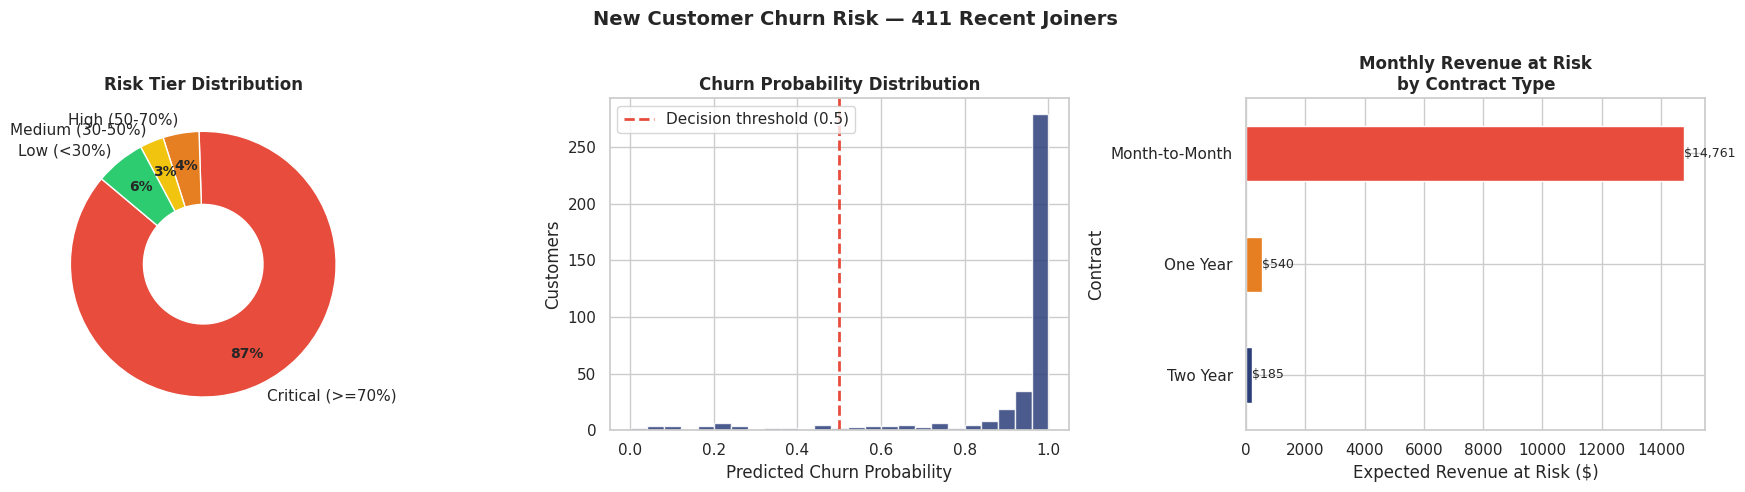


  Saved → 4_business_insights.png


In [21]:
# ── 7.1  Business Insights Figure ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("New Customer Churn Risk — 411 Recent Joiners", fontsize=14, fontweight="bold")

ax = axes[0]
tier_order  = ["Critical (>=70%)", "High (50-70%)", "Medium (30-50%)", "Low (<30%)"]
tier_colors = {"Critical (>=70%)": RED, "High (50-70%)": ORANGE,
               "Medium (30-50%)": "#F1C40F", "Low (<30%)": GREEN}
tier_counts = join_df["Risk_Tier"].value_counts().reindex(tier_order, fill_value=0)
wedges, texts, autotexts = ax.pie(tier_counts, labels=tier_counts.index,
    autopct="%1.0f%%", colors=[tier_colors[t] for t in tier_counts.index],
    startangle=140, pctdistance=0.75, wedgeprops=dict(width=0.55))
for at in autotexts: at.set_fontsize(10); at.set_fontweight("bold")
ax.set_title("Risk Tier Distribution", fontsize=12, fontweight="bold")

ax = axes[1]
ax.hist(join_df["Churn_Probability"], bins=25, color=BLUE, edgecolor="white", alpha=0.85)
ax.axvline(0.5, color=RED, lw=2, linestyle="--", label="Decision threshold (0.5)")
ax.set_title("Churn Probability Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Churn Probability"); ax.set_ylabel("Customers"); ax.legend()

ax = axes[2]
rev_by_contract = join_df.groupby("Contract")["Revenue_at_Risk"].sum().sort_values()
bar_colors = [BLUE, ORANGE, RED][:len(rev_by_contract)]
rev_by_contract.plot(kind="barh", ax=ax, color=bar_colors, edgecolor="white")
ax.set_title("Monthly Revenue at Risk\nby Contract Type", fontsize=12, fontweight="bold")
ax.set_xlabel("Expected Revenue at Risk ($)")
for i, v in enumerate(rev_by_contract.values):
    ax.text(v + 5, i, f"${v:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/4_business_insights.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Saved → 4_business_insights.png")

In [22]:
# ── 7.2  Export to Excel ──────────────────────────────────────────────────────
pred_out = (join_df[["Customer_ID", "Age", "Contract", "Internet_Type",
                       "Monthly_Charge", "Tenure_in_Months",
                       "Churn_Probability", "Risk_Tier",
                       "Revenue_at_Risk", "Retention_Action"]]
            .copy()
            .sort_values("Churn_Probability", ascending=False)
            .reset_index(drop=True))
pred_out["Churn_Probability"] = pred_out["Churn_Probability"].round(3)
pred_out.to_excel(f"{OUTPUT_DIR}/5_churn_predictions.xlsx", index=False)
print(f"\n  Saved → 5_churn_predictions.xlsx  ({len(pred_out)} rows)")
print(f"  Top 5 highest-risk customers:")
print(pred_out[["Customer_ID","Contract","Monthly_Charge","Churn_Probability","Risk_Tier"]].head())


  Saved → 5_churn_predictions.xlsx  (411 rows)
  Top 5 highest-risk customers:
  Customer_ID        Contract  Monthly_Charge  Churn_Probability  \
0   52641-JHA  Month-to-Month       71.099998              1.000   
1   16733-ODI  Month-to-Month       45.849998              0.999   
2   28681-HAR  Month-to-Month       75.550003              0.999   
3   37131-MAH  Month-to-Month       89.250000              0.999   
4   94070-JAM  Month-to-Month       90.099998              0.999   

          Risk_Tier  
0  Critical (>=70%)  
1  Critical (>=70%)  
2  Critical (>=70%)  
3  Critical (>=70%)  
4  Critical (>=70%)  


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("PROJECT COMPLETE — FULL PIPELINE SUMMARY")
print("="*65)
print(f"""
Phase 1 — SQL Server
  Views created     : vw_ChurnData, vw_JoinData
  Records prepared  : 6,007 + 411

Phase 2 — Power BI
  Pages built       : Summary, Churn Reason
  Visuals           : 15 visuals, 2 DAX measures tables
  Key findings      : 5 patterns feeding Phase 3

Phase 3 — Machine Learning
  Features used     : {len(ALL_FEATURES)} (including {len(ENGINEERED_FEATURES)} engineered)
  Training strategy : 80/20 stratified split + SMOTE
  Models trained    : Logistic Regression, Random Forest, XGBoost
  Best model        : {best_name}
  Best ROC-AUC      : {results[best_name]['roc_auc']:.4f}
  Best Accuracy     : {results[best_name]['accuracy']:.4f}

Deployment Output
  Customers scored  : 411
  High-risk (≥50%)  : {(join_df['Churn_Probability'] >= 0.5).sum()} customers
  Revenue at risk   : ${join_df['Revenue_at_Risk'].sum():,.0f} / month
  Outputs saved to  : {OUTPUT_DIR}/
""")
print("="*65)


PROJECT COMPLETE — FULL PIPELINE SUMMARY

Phase 1 — SQL Server
  Views created     : vw_ChurnData, vw_JoinData
  Records prepared  : 6,007 + 411

Phase 2 — Power BI
  Pages built       : Summary, Churn Reason
  Visuals           : 15 visuals, 2 DAX measures tables
  Key findings      : 5 patterns feeding Phase 3

Phase 3 — Machine Learning
  Features used     : 34 (including 6 engineered)
  Training strategy : 80/20 stratified split + SMOTE
  Models trained    : Logistic Regression, Random Forest, XGBoost
  Best model        : XGBoost
  Best ROC-AUC      : 0.8873
  Best Accuracy     : 0.8453

Deployment Output
  Customers scored  : 411
  High-risk (≥50%)  : 374 customers
  Revenue at risk   : $15,486 / month
  Outputs saved to  : /content/outputs/

